# 01 - Exploratory Data Analysis (EDA)

## SDG 13: Vehicle CO2 Emissions Prediction

This notebook performs exploratory data analysis on the Canadian vehicle CO2 emissions dataset. The goal is to understand data characteristics, identify quality issues, and discover patterns that inform the modeling strategy.

**Dataset**: [CO2 Emission by Vehicles (Kaggle)](https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles)
**Size**: 7,385 records × 12 features
**Target Variable**: CO2 Emissions (g/km)

### Analysis Roadmap
1. Data overview and structure
2. Numerical feature statistics
3. Categorical feature distribution
4. Target variable distribution
5. Feature-target relationships
6. Correlation analysis
7. Key findings and preprocessing decisions

## 1. Setup and Data Loading

Import required libraries and load the raw dataset from `data/raw/`.

In [23]:
import pandas as pd

In [32]:
df = pd.read_csv('../data/raw/CO2 Emissions_Canada.csv')

### 1.1 First Look at the Data

Preview the first 5 rows to understand the column structure.

In [33]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## 2. Data Structure Overview

### 2.1 Dataset Dimensions

In [34]:
df.shape

(7385, 12)

### 2.2 Column Types and Missing Values

Inspect column data types and check for missing entries.

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

## 3. Numerical Feature Statistics

Summary statistics reveal the range and distribution of numerical features, including our target variable.

In [7]:
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


## 4. Categorical Feature Distribution

Examine the distribution of categorical variables to detect class imbalance and high-cardinality issues.

### 4.1 Fuel Type

In [8]:
df['Fuel Type'].value_counts()

Fuel Type
X    3637
Z    3202
E     370
D     175
N       1
Name: count, dtype: int64

### 4.2 Vehicle Class

In [9]:
df['Vehicle Class'].value_counts()

Vehicle Class
SUV - SMALL                 1217
MID-SIZE                    1133
COMPACT                     1022
SUV - STANDARD               735
FULL-SIZE                    639
SUBCOMPACT                   606
PICKUP TRUCK - STANDARD      538
TWO-SEATER                   460
MINICOMPACT                  326
STATION WAGON - SMALL        252
PICKUP TRUCK - SMALL         159
MINIVAN                       80
SPECIAL PURPOSE VEHICLE       77
VAN - PASSENGER               66
STATION WAGON - MID-SIZE      53
VAN - CARGO                   22
Name: count, dtype: int64

### 4.3 Make (Brand)

In [10]:
df['Make'].value_counts()

Make
FORD             628
CHEVROLET        588
BMW              527
MERCEDES-BENZ    419
PORSCHE          376
TOYOTA           330
GMC              328
AUDI             286
NISSAN           259
JEEP             251
DODGE            246
KIA              231
HONDA            214
HYUNDAI          210
MINI             204
VOLKSWAGEN       197
MAZDA            180
LEXUS            178
JAGUAR           160
CADILLAC         158
SUBARU           140
VOLVO            124
INFINITI         108
BUICK            103
RAM               97
LINCOLN           96
MITSUBISHI        95
CHRYSLER          88
LAND ROVER        85
FIAT              73
ACURA             72
MASERATI          61
ROLLS-ROYCE       50
ASTON MARTIN      47
BENTLEY           46
LAMBORGHINI       41
ALFA ROMEO        30
GENESIS           25
SCION             22
SMART              7
BUGATTI            3
SRT                2
Name: count, dtype: int64

### 4.4 Transmission

In [11]:
df['Transmission'].value_counts()

Transmission
AS6     1324
AS8     1211
M6       901
A6       789
A8       490
AM7      445
A9       339
AS7      319
AV       295
M5       193
AS10     168
AM6      132
AV7      118
AV6      113
M7        91
A5        84
AS9       77
A4        65
AM8       62
A7        53
AV8       39
A10       31
AS5       26
AV10      11
AM5        4
AM9        3
AS4        2
Name: count, dtype: int64

## 5. Visual Exploration

Import visualization libraries and explore the data graphically.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

### 5.1 Target Variable Distribution

Understand the shape of CO2 emissions distribution — is it normal, skewed, or multimodal?

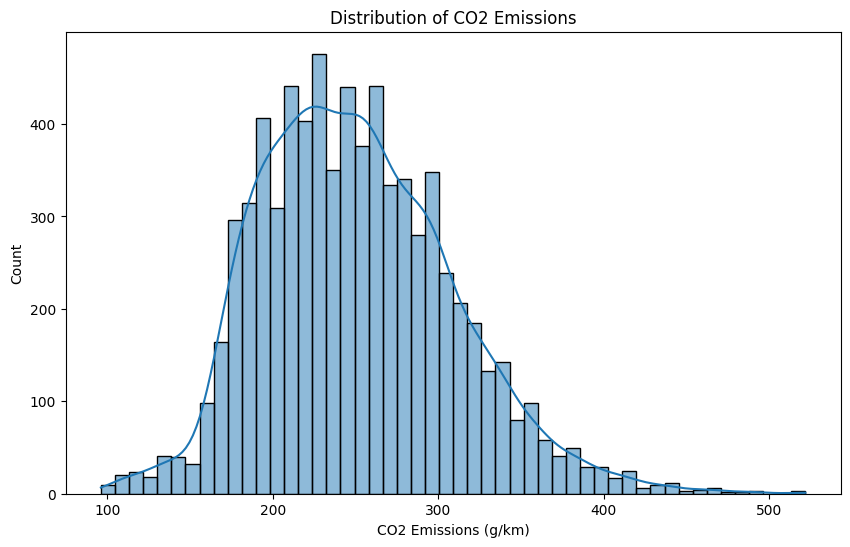

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='CO2 Emissions(g/km)', bins=50, kde=True)
plt.title('Distribution of CO2 Emissions')
plt.xlabel('CO2 Emissions (g/km)')
plt.ylabel('Count')
plt.show()

### 5.2 Fuel Consumption vs CO2 Emissions

Examine the relationship between fuel consumption (expected to be the strongest predictor) and the target.

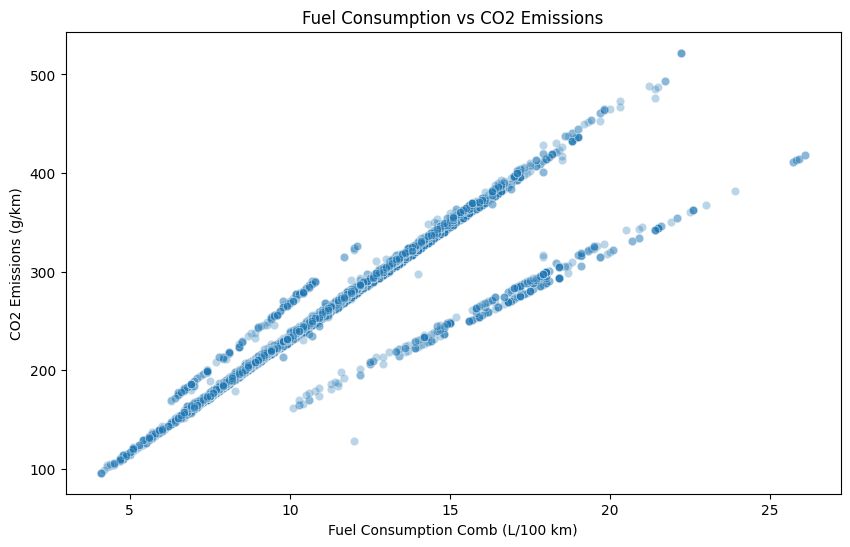

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fuel Consumption Comb (L/100 km)', y='CO2 Emissions(g/km)', alpha=0.3)
plt.title('Fuel Consumption vs CO2 Emissions')
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

### 5.3 Fuel Consumption vs CO2 Emissions — by Fuel Type

Color-coding by fuel type reveals whether fuel composition changes the fuel-to-emission relationship.

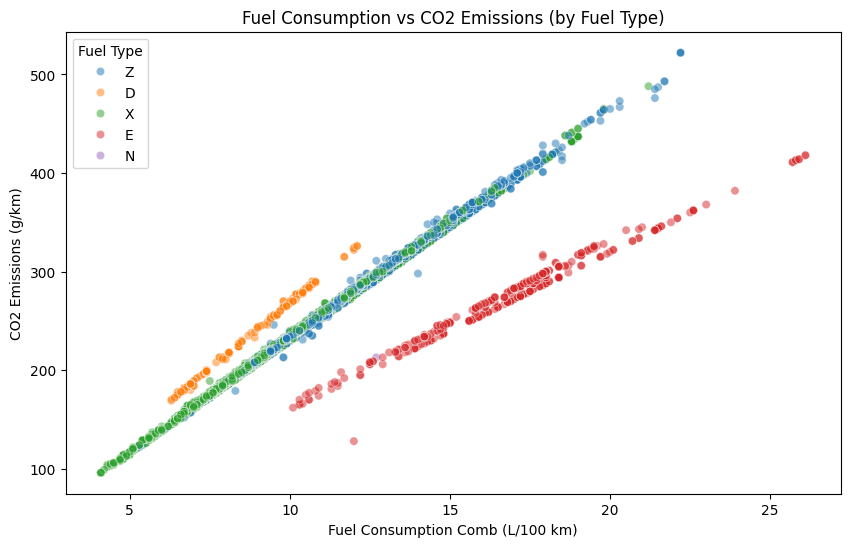

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fuel Consumption Comb (L/100 km)', 
                y='CO2 Emissions(g/km)', 
                hue='Fuel Type', 
                alpha=0.5)
plt.title('Fuel Consumption vs CO2 Emissions (by Fuel Type)')
plt.xlabel('Fuel Consumption Comb (L/100 km)')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

### 5.4 Correlation Heatmap

Quantify linear relationships between numerical features and detect multicollinearity.

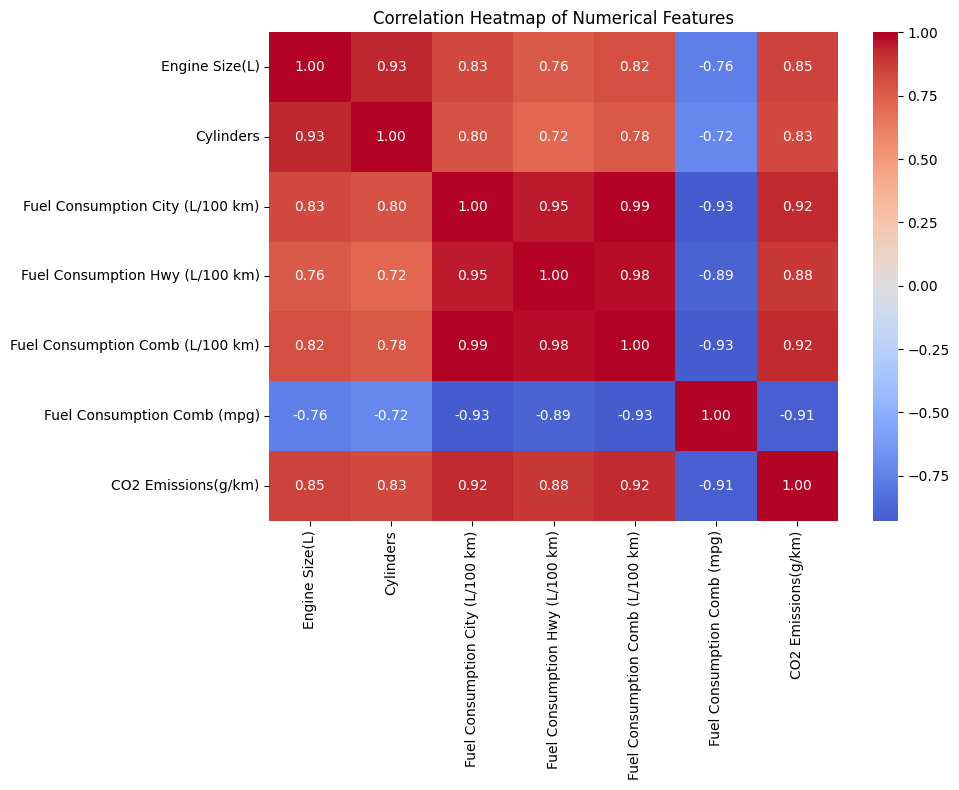

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### 5.5 CO2 Emissions by Fuel Type

Compare the distribution of CO2 emissions across fuel categories.

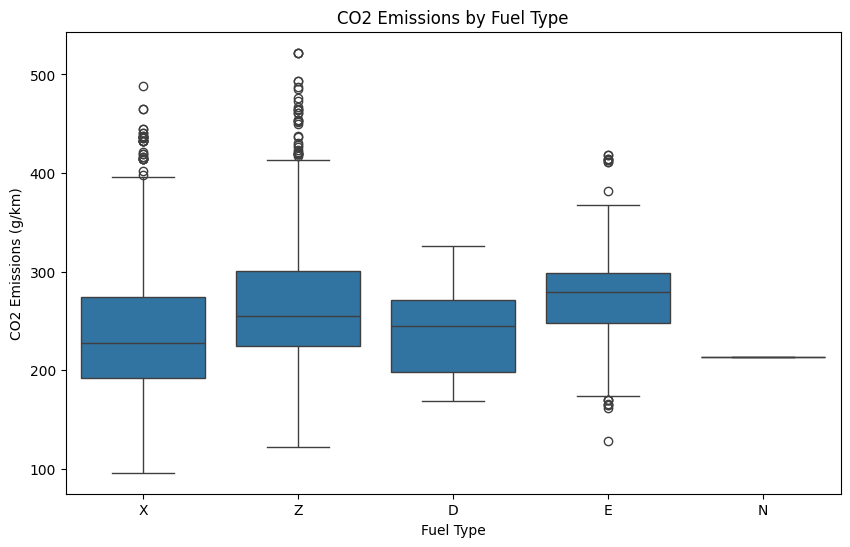

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fuel Type', y='CO2 Emissions(g/km)', order=['X', 'Z', 'D', 'E', 'N'])
plt.title('CO2 Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

## 6. Key Findings and Preprocessing Decisions

### 6.1 Data Quality Summary

- **Size**: 7,385 records × 12 features
- **Missing Values**: None — the dataset is clean with no missing entries
- **Data Types**: 7 numerical features (int/float) and 5 categorical features (string)

### 6.2 Target Variable (CO2 Emissions)

- Range: **96 to 522 g/km** (over 5× difference between cleanest and most polluting vehicle)
- Mean: **250.6 g/km**, Median: **246 g/km**
- Distribution is **right-skewed** — most vehicles cluster in the 200–300 g/km range, with a long tail of high-emission vehicles (SUVs, pickups, supercars)

### 6.3 Feature Relationships

**Strongest predictors of CO2 emissions** (by correlation coefficient):
- `Fuel Consumption Comb (L/100 km)`: **+0.92**
- `Fuel Consumption City`: **+0.92**
- `Fuel Consumption Comb (mpg)`: **-0.91** (inverse unit)
- `Engine Size`: **+0.85**
- `Cylinders`: **+0.83**

### 6.4 Critical Discoveries

#### 🔍 Fuel Type Creates Distinct Emission Patterns
The scatter plot colored by fuel type reveals **three separate linear trends** rather than one. At the same fuel consumption:
- **Diesel (D)** has the highest emission coefficient per liter (~2.68 kg CO2/L)
- **Gasoline (X/Z)** sits in the middle (~2.31 kg CO2/L)  
- **Ethanol (E)** has the lowest per-liter coefficient

This indicates a **feature interaction** — linear models alone cannot capture this pattern; tree-based models (Random Forest, XGBoost) are better suited.

#### 🔍 Counter-intuitive Finding: Ethanol Vehicles Emit the Most Overall
Despite ethanol's lower per-liter CO2 coefficient, the boxplot shows **ethanol vehicles have the highest median CO2 emissions (~275 g/km)**. This is because ethanol's low energy density forces higher total fuel consumption, which outweighs the per-liter savings. This challenges the assumption that biofuels are automatically climate-friendly.

#### 🔍 Multicollinearity Among Fuel Consumption Features
The three fuel consumption columns (City, Hwy, Comb) have correlations above **0.95** with each other. Retaining all three would destabilize linear regression coefficients without adding predictive value.

### 6.5 Class Imbalance Issues

- **Fuel Type N (Natural Gas)**: only **1 record** — insufficient for learning
- **Vehicle Class**: 16 categories, imbalanced (VAN-CARGO: 22 vs SUV-SMALL: 1217)
- **Make**: 40+ brands with long-tail distribution (BUGATTI: 3, FORD: 628)
- **Transmission**: 27 unique values, some with very few samples

### 6.6 Preprocessing Decisions for Next Notebook

Based on these findings, `02_preprocessing.ipynb` will implement:

| Column | Action | Rationale |
|---|---|---|
| `Model` | Drop | 2000+ unique values, uninformative after brand removal |
| `Fuel Consumption City` | Drop | Multicollinear with Comb (r=0.99) |
| `Fuel Consumption Hwy` | Drop | Multicollinear with Comb (r=0.98) |
| `Fuel Consumption Comb (mpg)` | Drop | Inverse of L/100km column (r=-0.93) |
| `Fuel Type = N` row | Drop | Only 1 sample, cannot learn |
| `Make` | Consider dropping | High cardinality, long-tail |
| `Vehicle Class`, `Transmission`, `Fuel Type` | One-Hot Encode | Manageable cardinality |
| `Engine Size`, `Cylinders`, `Fuel Consumption Comb` | StandardScaler | Different scales |

### 6.7 Modeling Strategy Implications

The EDA suggests:
1. **Linear Regression** will serve as a baseline but is expected to underperform due to fuel-type-dependent interactions
2. **Random Forest / XGBoost** should capture the non-linear interactions between fuel type and fuel consumption, as well as feature importance rankings
3. **Evaluation metric**: RMSE and R² on test set; residual analysis by fuel type to verify the model handles all fuel categories well